# Линейная регрессия на собственном датасете

## Содержание

0. Загрузка своего датасета (Kaggle)
1. Быстрый разведочный анализ (EDA) на новом датасете
2. Подготовка данных к регрессии
3. Обучение линейной регрессии
4. Оценка качества модели (метрики)
5. Интерпретация коэффициентов
6. Практикум

Это занятие продолжает пайплайн из первого блокнота (очистка → EDA → модель), только теперь вы применяете его к **своему** датасету с Kaggle. Если в вашем датасете чего-то из первого занятия ещё не хватает (пропуски, дубликаты, аномалии) — сначала доведите данные до состояния `df_clean`, как на первом занятии, и только потом переходите к регрессии.

## 0. Загрузка своего датасета

Перед началом убедитесь, что:
- датасет табличный (не картинки и не текст);
- в нём есть понятная **числовая** целевая переменная (то, что мы будем предсказывать) — например, цена, рейтинг, доход, время;
- строк не менее ~1000.

Скачайте `.csv` с Kaggle и положите его рядом с блокнотом (или загрузите через `files.upload()` в Google Colab).

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Укажите путь к вашему файлу
FILE_PATH = "housing.csv"

df = pd.read_csv(FILE_PATH)
print("Размер таблицы:", df.shape)
df.head()

Размер таблицы: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Задача 0.**
Опишите словами в ячейке ниже (markdown):
- что предсказывает ваша модель (какая целевая переменная и в каких единицах измеряется);
- откуда взяты данные (ссылка на Kaggle);
- какая бизнес-задача стоит за этим прогнозом (кому и зачем нужен этот прогноз).

**Ваш ответ:**

Целевой переменной является колонка median_house_value, в ней находятся медианная стоимость дома в районе. Измеряется в долларах США.

https://www.kaggle.com/datasets/camnugent/california-housing-prices

Бизнес-задача: построить модель, предсказывающая fairy-price домов. Она может быть интегрирована на сайт по продаже вторичных домов.

## 1. Быстрый разведочный анализ (EDA)

Прежде чем строить модель, ещё раз убедитесь, что данные в порядке — коротко повторяем шаги первого занятия.

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [25]:
display(df.describe())
print("Пропуски по столбцам:")
print(df.isna().sum())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Пропуски по столбцам:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


**Задача 1.**
Если в данных остались пропуски или дубликаты — обработайте их (как на первом занятии) и сохраните результат в `df_clean`. Если данные уже чистые — просто продублируйте `df` в `df_clean`.

In [26]:
df["total_bedrooms"].isna().mean()

np.float64(0.01002906976744186)

In [27]:
df_clean = df.dropna().reset_index()
df_clean.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Задача 2.**
Постройте гистограмму распределения вашей целевой переменной. Опишите в ячейке «Вывод», нормальное ли у неё распределение, есть ли перекос (skew) или явные выбросы.

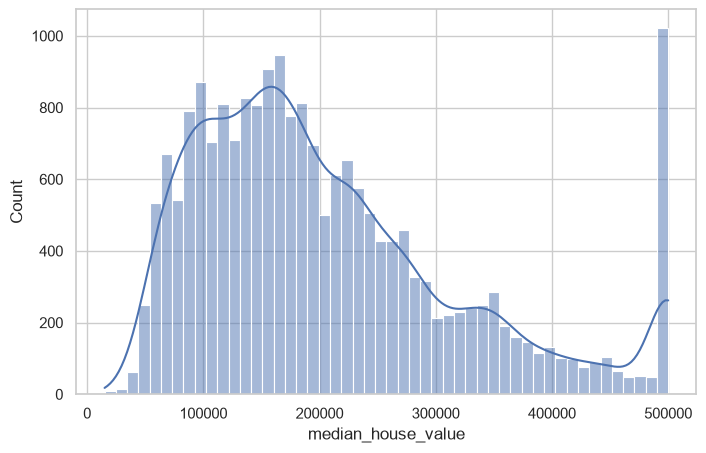

In [28]:
sns.histplot(df_clean['median_house_value'], bins=50, kde=True)
plt.show()

**Вывод:**

Наблюдается перекос влево, видны аномальные наблюдения (сверх дорогие дома)

## 2. Подготовка данных к регрессии

Модели линейной регрессии нужны **числа** на входе. Категориальные признаки (текстовые столбцы) нужно закодировать, например через `pd.get_dummies()`. Дальше данные делятся на обучающую и тестовую выборки — модель обучается на одной части и проверяется на другой, которую не видела.

In [29]:
from sklearn.model_selection import train_test_split

TARGET = "median_house_value"  # замените на имя вашей целевой переменной

# Кодируем категориальные признаки
X = pd.get_dummies(df_clean.drop(columns=[TARGET]), drop_first=True)
X = X.drop(columns=['index'])
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (16346, 12)
Тестовая выборка: (4087, 12)


**Задача 3.**
Проверьте, не остались ли в `X` нечисловые столбцы (например, даты как объекты) после `get_dummies()`. Если остались — либо удалите их, либо превратите в числовые признаки (например, извлеките месяц/год из даты, как на первом занятии).

In [30]:
X.dtypes

longitude                     float64
latitude                      float64
housing_median_age            float64
total_rooms                   float64
total_bedrooms                float64
population                    float64
households                    float64
median_income                 float64
ocean_proximity_INLAND           bool
ocean_proximity_ISLAND           bool
ocean_proximity_NEAR BAY         bool
ocean_proximity_NEAR OCEAN       bool
dtype: object

## 3. Обучение линейной регрессии

### Математический аппарат

Линейная регрессия ищет такие коэффициенты $\beta$, при которых предсказание

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

как можно ближе к реальному значению $y$ — модель минимизирует сумму квадратов ошибок:

$$\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 \rightarrow \min$$

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 4. Оценка качества модели

Одной метрики обычно недостаточно — они показывают разные стороны качества модели.

**MAE (Mean Absolute Error)** — средняя абсолютная ошибка, в тех же единицах, что и целевая переменная. Легко интерпретируется («в среднем ошибаемся на N рублей»), но одинаково штрафует и маленькие, и большие ошибки:

$$MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$

**MSE (Mean Squared Error)** — среднеквадратичная ошибка. Из-за возведения в квадрат сильнее штрафует большие ошибки (выбросы в предсказаниях «стоят дороже»):

$$MSE = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**RMSE (Root Mean Squared Error)** — корень из MSE. В отличие от MSE, измеряется в тех же единицах, что и целевая переменная, поэтому удобнее для интерпретации:

$$RMSE = \sqrt{MSE}$$

**MAPE (Mean Absolute Percentage Error)** — средняя ошибка в процентах от реального значения. Удобна, когда нужно сравнивать качество модели на данных с разным масштабом (например, между регионами с разными ценами):

$$MAPE = \frac{100\%}{n}\sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

*Осторожно: MAPE «ломается», если среди значений $y_i$ встречаются нули или значения, близкие к нулю.*

**R² (коэффициент детерминации)** — доля дисперсии целевой переменной, объяснённая моделью:

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

- $R^2 = 1$ — идеальное предсказание;
- $R^2 = 0$ — модель не лучше, чем просто предсказывать среднее значение $\bar{y}$ для всех объектов;
- $R^2 < 0$ — модель хуже, чем предсказание средним (бывает на тестовой выборке при переобучении).

**Как выбирать метрику:** если в задаче важны единицы измерения и крупные ошибки критичны (например, прогноз бюджета) — смотрите на RMSE; если нужна устойчивость к выбросам — на MAE; если нужно сравнивать модели между разными масштабами данных — на MAPE; R² полезен для быстрой оценки «на глаз», но сам по себе не заменяет остальные метрики.

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# MAPE считаем вручную, отбросив нулевые значения y_test
mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.1f}%")
print(f"R2:   {r2:.3f}")

MAE:  50413.43
MSE:  4802173538.60
RMSE: 69297.72
MAPE: 28.6%
R2:   0.649


**Задача 4.**
Постройте scatter-график: по оси X — реальные значения `y_test`, по оси Y — предсказанные `y_pred`. Добавьте диагональную линию (идеальное предсказание). Опишите в «Выводе», где модель ошибается больше всего.

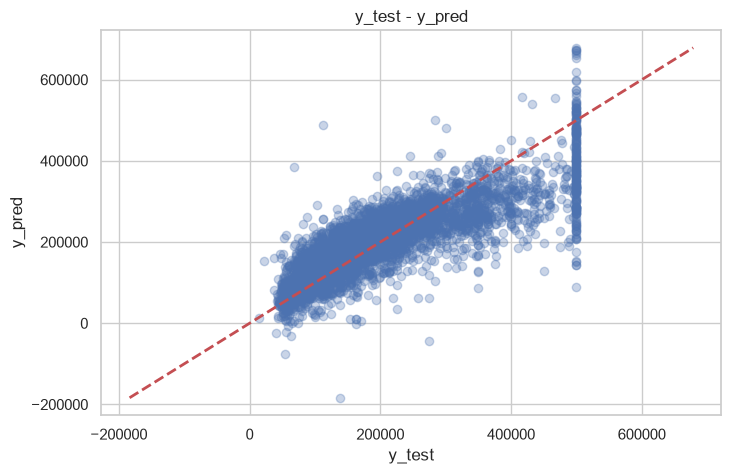

In [33]:
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())

plt.scatter(x=y_test, y=y_pred, alpha=0.3)
plt.plot([lo, hi], [lo, hi], "r--", linewidth=2, label="Идеальное предсказание (y = x)")
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('y_test - y_pred')
plt.show()

**Вывод:**

Как видно из графика, есть корреляция между тестовыми и предсказанными результатами (нет случайной подстановки значений). Но результат далёк от иделала. Также видно, что модель часто даёт слишком высокие числа. Это происходит из-за того, что данном pipeline мы не боролись с выбросами.

**Задача 4.1.**
Сравните MAE и RMSE вашей модели. Если RMSE заметно больше MAE — это признак того, что на некоторых объектах модель ошибается особенно сильно (выбросы в ошибках). Найдите 5 объектов тестовой выборки с наибольшей ошибкой предсказания и опишите, что их объединяет.

In [34]:
print(np.abs(mae - rmse) / mae * 100, "%")


37.45883218787872 %


**Вывод:**

Как видно, разница довольно большая. На некоторых объектах модель ошибается особо сильно, это происходит из-за аномалий в датасете.

## 5. Интерпретация коэффициентов

Коэффициенты линейной регрессии показывают, как меняется прогноз при изменении признака на единицу (при неизменных остальных).

In [35]:
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
coefficients.head(10)

ocean_proximity_ISLAND        213653.374463
median_income                  39277.083020
ocean_proximity_INLAND        -39240.217778
longitude                     -27108.746321
latitude                      -25657.807543
ocean_proximity_NEAR BAY       -6232.416876
ocean_proximity_NEAR OCEAN      3166.477128
housing_median_age              1081.364206
total_bedrooms                   103.004042
households                        43.142725
dtype: float64

**Задача 5.**
Назовите 3 признака с наибольшим по модулю коэффициентом. Дают ли они интуитивно понятный результат с точки зрения вашей предметной области, или что-то выглядит подозрительно (см. P.S. в конце блокнота про мультиколлинеарность)?

**Ваш ответ:**

Наибольшие по модулю признаки: океан и остров, средний заработок, океан и без острова, долгота, широта. Они дают интуитивно понятный результат

## 6. Практикум

**Задание 6.1.** Обучите вторую модель — `LinearRegression`, но на другом наборе признаков (например, уберите 2-3 признака с наименьшей значимостью, судя по коэффициентам). Сравните все метрики (MAE/RMSE/MAPE/R²) с исходной моделью.

In [36]:
features_to_drop = coefficients.tail(3).index.tolist()
features_to_drop

['households', 'population', 'total_rooms']

In [37]:
lin_reg = LinearRegression().fit(X_train[features_to_drop], y_train)
y_pred2 = lin_reg.predict(X_test[features_to_drop])

In [39]:
mae2 = mean_absolute_error(y_test, y_pred2)
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
r22 = r2_score(y_test, y_pred2)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.1f}%")
print(f"R2:   {r2:.3f}")
print("-" * 30)
print(f"MAE:  {mae2:.2f}")
print(f"MSE:  {mse2:.2f}")
print(f"RMSE: {rmse2:.2f}")
print(f"R2:   {r22:.3f}")

MAE:  50413.43
MSE:  4802173538.60
RMSE: 69297.72
MAPE: 28.6%
R2:   0.649
------------------------------
MAE:  87771.05
MSE:  12347374112.98
RMSE: 111118.74
R2:   0.097


**Вывод:**

Очень большая просадка метрик, хоть и исключены самые слабые признаки

**Задание 6.2.** Постройте гистограмму остатков (`y_test - y_pred`). В идеале остатки должны быть распределены симметрично вокруг нуля. Опишите, что видите на графике.

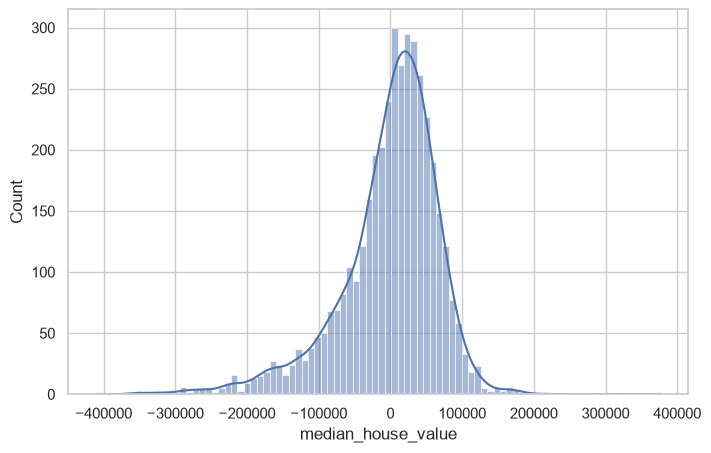

In [41]:
sns.histplot(y_pred - y_test, kde=True)
plt.show()

**Вывод:**

Не сильно симметрично, но винда структура распределения остатков

**Задание 6.3.** Постройте scatter-график остатков (`y_test - y_pred`) в зависимости от предсказанных значений `y_pred`. Если точки образуют явный «веер» или дугу (а не случайное облако вокруг нуля) — это признак того, что модель не улавливает нелинейную зависимость в данных. Опишите, что видите.

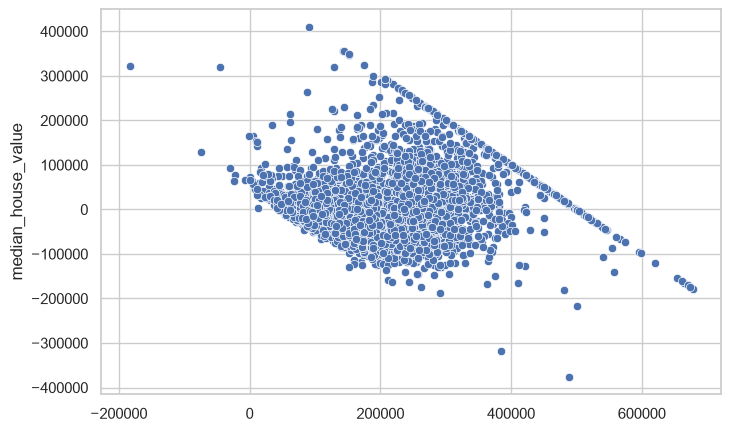

In [42]:
sns.scatterplot(x=y_pred, y=(y_test - y_pred))
plt.show()

**Вывод:**

Видны границы широкой линии. но в целом центрируется облако точек

**Задание 6.4.** Посчитайте матрицу корреляций между числовыми признаками в `X_train` (`X_train.corr()`) и визуализируйте её через `sns.heatmap()`. Найдите пары признаков с корреляцией выше 0.8 по модулю — это кандидаты на мультиколлинеарность (см. P.S. ниже).

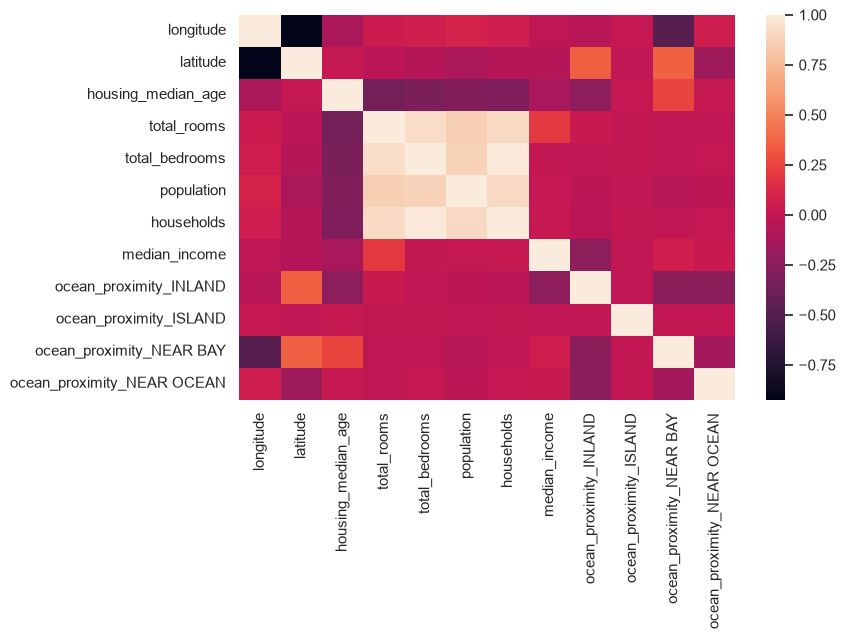

In [44]:
sns.heatmap(X_train.corr())
plt.show()

**Вывод:**

Видна большая корреляция между total_amounts, total_bedrooms, population, households. Боьшая отрицательная корреляция между latitude и longitude

**Задание 6.5.** Попробуйте обучить модель только на 3-5 признаках, которые вы считаете наиболее важными по смыслу задачи (не по коэффициентам, а по своей экспертной оценке). Сравните метрики с полной моделью — сильно ли просела точность при сильном сокращении числа признаков?

In [46]:
features = ["median_income", "latitude", "longitude", 
            "housing_median_age", "total_rooms"]

lin_reg_2 = LinearRegression().fit(X_train[features], y_train)
y_pred3 = lin_reg_2.predict(X_test[features])

mae3 = mean_absolute_error(y_test, y_pred3)
mse3 = mean_squared_error(y_test, y_pred3)
rmse3 = np.sqrt(mse3)
r23 = r2_score(y_test, y_pred3)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.1f}%")
print(f"R2:   {r2:.3f}")
print("-" * 30)
print(f"MAE:  {mae3:.2f}")
print(f"MSE:  {mse3:.2f}")
print(f"RMSE: {rmse3:.2f}")
print(f"R2:   {r23:.3f}")

MAE:  50413.43
MSE:  4802173538.60
RMSE: 69297.72
MAPE: 28.6%
R2:   0.649
------------------------------
MAE:  54814.72
MSE:  5508742980.14
RMSE: 74220.91
R2:   0.597


**Вывод:**

Наблюдается не очень сильная просадка метрик. Видимо, подобрал хорошие признаки

**Задание 6.6. Итоговое резюме.**
В 5-7 предложениях опишите: какую задачу решала модель, насколько хорошо она справилась (с опорой на все метрики, а не только на R²), какие признаки оказались важнее всего, обнаружили ли вы мультиколлинеарность, и что бы вы попробовали улучшить в следующей итерации (новые признаки, другая модель, больше данных).

**Резюме:**

Модель решала задачу регрессии — предсказание медианной стоимости дома (`median_house_value`) в районах Калифорнии по табличным признакам, что может использоваться для оценки справедливой цены на сайте недвижимости. Полная линейная регрессия показала умеренное качество: MAE ≈ 50 413, RMSE ≈ 69 298, MAPE ≈ 28.6%, R² ≈ 0.649, то есть модель объясняет около 65% разброса цен, но средняя абсолютная ошибка остаётся существенной. При сокращении до 5 экспертно выбранных признаков (`median_income`, `latitude`, `longitude`, `housing_median_age`, `total_rooms`) качество просело не катастрофически: MAE ≈ 54 815, RMSE ≈ 74 221, R² ≈ 0.597, что подтверждает высокую важность дохода и географического положения. В полной модели также важны `ocean_proximity` и `median_income`, а среди числовых признаков заметный вклад дают координаты и доход; при этом признаки `total_rooms`, `total_bedrooms`, `population`, `households` сильно коррелированы, как и `latitude` с `longitude`, что указывает на мультиколлинеарность и нестабильность коэффициентов. Остатки и график `y_test–y_pred` показывают нелинейность, гетероскедастичность и сильные ошибки на дорогих/аномальных объектах, поэтому одной линейной модели недостаточно. В следующей итерации стоит добавить производные признаки (комнаты на семью, спальни на комнату, население на домохозяйство), обработать выбросы и дорогие объекты, попробовать логарифмирование целевой переменной, регуляризацию (Ridge/Lasso) и нелинейные модели (Random Forest/Gradient Boosting) с кросс-валидацией.

---

## P.S. Что такое мультиколлинеарность

**Мультиколлинеарность** — это ситуация, когда два (или больше) признака в данных сильно коррелируют друг с другом, то есть фактически несут одну и ту же информацию. Например, «площадь квартиры в м²» и «количество комнат» обычно сильно связаны между собой: чем больше комнат, тем больше площадь.

**Почему это проблема для линейной регрессии.** Модель пытается «разделить» вклад каждого признака в прогноз через отдельный коэффициент. Если два признака почти дублируют друг друга, модели становится сложно понять, какому из них приписать влияние на целевую переменную — коэффициенты становятся нестабильными: небольшое изменение данных (например, добавили несколько новых строк) может резко изменить значения коэффициентов, а иногда даже поменять их знак на противоположный. При этом само качество прогноза (метрики MAE/RMSE/R² на тесте) может почти не пострадать — страдает именно **интерпретируемость** модели.

**Как заметить.** Матрица корреляций между признаками (задание 6.4) — самый простой способ. Более строгий инструмент — **VIF (Variance Inflation Factor)**, который показывает, насколько дисперсия коэффициента конкретного признака увеличена из-за его связи с остальными признаками:

$$VIF_j = \frac{1}{1 - R_j^2}$$

где $R_j^2$ — коэффициент детерминации регрессии $j$-го признака на все остальные признаки. Обычно считается, что $VIF > 5-10$ указывает на существенную мультиколлинеарность.

**Что с этим делать.** Убрать один из пары сильно коррелирующих признаков; объединить несколько похожих признаков в один (например, через PCA); либо использовать регуляризацию (Ridge-регрессию) — она специально устойчива к мультиколлинеарности и будет темой одного из следующих занятий.

### Справочные материалы

- Документация scikit-learn (Linear Regression): https://scikit-learn.org/stable/modules/linear_model.html
- Метрики регрессии в scikit-learn: https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics